In [707]:
# Первая часть - исследование

In [790]:
## Описание задачи 
### В данной работе предстоит моделировать отток клиентов телеком компании.
### Целевым признаком является столбец Church (Отток) в данных.
### Эта задача очень важна на практике и алгоритмы для ее решения используются в реальных 
### телеком компаниях, ведь если мы знаем, что клиент собирается уйти от нас, 
### то мы попытаться удержать его, предложив какие-то бонусы. 

In [791]:
import kagglehub

path = kagglehub.competition_download('advanced-dls-spring-2021')
kagglehub.whoami()

Kaggle credentials successfully validated.


{'username': 'seradrug'}

In [792]:
## Импорты

In [793]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [794]:
## Загружаю данные

In [795]:
df = pd.read_csv(os.path.join(path, "train.csv"))
X_test = pd.read_csv(os.path.join(path, "test.csv"))

In [796]:
df = df.replace(" ", np.nan)

In [797]:
df["TotalSpent"] = df["TotalSpent"].astype(float)

In [798]:
filled_df = df.copy()

In [799]:
family_col = [
    "HasPartner",
    "HasChild",
]

In [800]:
service_col = [
    "HasMultiplePhoneNumbers",
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
    "HasOnlineTV",
    "HasMovieSubscription",
    "HasInternetService",
    "HasContractPhone",
    "PaymentMethod",
]

In [801]:
num_col = [
    "ClientPeriod",
    "MonthlySpending",
    "TotalSpent",
]

In [802]:
## Заполняем все NaN на среднее значение в столбце TotalSpent при условии, что таргет = 0

In [803]:
filled_df["TotalSpent"] = filled_df["TotalSpent"].fillna(filled_df["TotalSpent"].mean())

In [804]:
# Бинарная категоризация
filled_df["Sex"] = filled_df["Sex"].map({"Male": 1, "Female": 0}).astype(int)
yes_no_columns = [ 
    "HasPartner",
    "HasChild",
    "HasPhoneService",
    "IsBillingPaperless"
]

filled_df[yes_no_columns] = filled_df[yes_no_columns].replace({"Yes": 1, "No": 0}).astype(int)

In [805]:
filled_df[family_col] = filled_df[family_col].astype(int)

In [806]:
filled_df["Family"] = filled_df[family_col].sum(axis=1)

In [807]:
filled_df = filled_df.drop(columns=family_col)

In [808]:
filled_df.info(10)

<class 'pandas.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   float64
 3   Sex                       5282 non-null   int64  
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPhoneService           5282 non-null   int64  
 6   HasMultiplePhoneNumbers   5282 non-null   str    
 7   HasInternetService        5282 non-null   str    
 8   HasOnlineSecurityService  5282 non-null   str    
 9   HasOnlineBackup           5282 non-null   str    
 10  HasDeviceProtection       5282 non-null   str    
 11  HasTechSupportAccess      5282 non-null   str    
 12  HasOnlineTV               5282 non-null   str    
 13  HasMovieSubscription      5282 non-null   str    
 14  HasContractPhone   

In [809]:
X_train = filled_df.drop(columns="Churn")
y_train = filled_df["Churn"]

In [810]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [811]:
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(sparse_output=False), service_col),
      ("num", StandardScaler(), num_col)], remainder="passthrough")

preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [812]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [817]:
model = Pipeline(
    [('preprocessor', preprocessor), ("classifier", LogisticRegression(max_iter=1000))
    ])
model.fit(X_tr, y_tr)

models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "RandomFor": RandomForestClassifier(n_estimators=500, random_state=42),
}

In [818]:
for name, clf in models.items():
    pipe = Pipeline(
        [('prepocessor', preprocessor), ("classifier", clf)])
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    print(
        name,
        scores.mean(),
        scores.std()
    )

LogReg 0.8447900065030339 0.02050115253579236
RandomFor 0.8235164953491398 0.018658690662720932


In [819]:
y_val_pred = model.predict(X_val)

In [820]:
score = roc_auc_score(y_val, y_val_pred)
score

0.6882486308770699

In [756]:
## Baseline (logregression, score - 0.68) 

In [757]:
filled_df = preprocessor.fit_transform(filled_df)

In [758]:
corr = filled_df.corr()

In [759]:
target = (corr[["remainder__Churn"]].drop(index="remainder__Churn").sort_values("remainder__Churn"))

<function matplotlib.pyplot.show(close=None, block=None)>

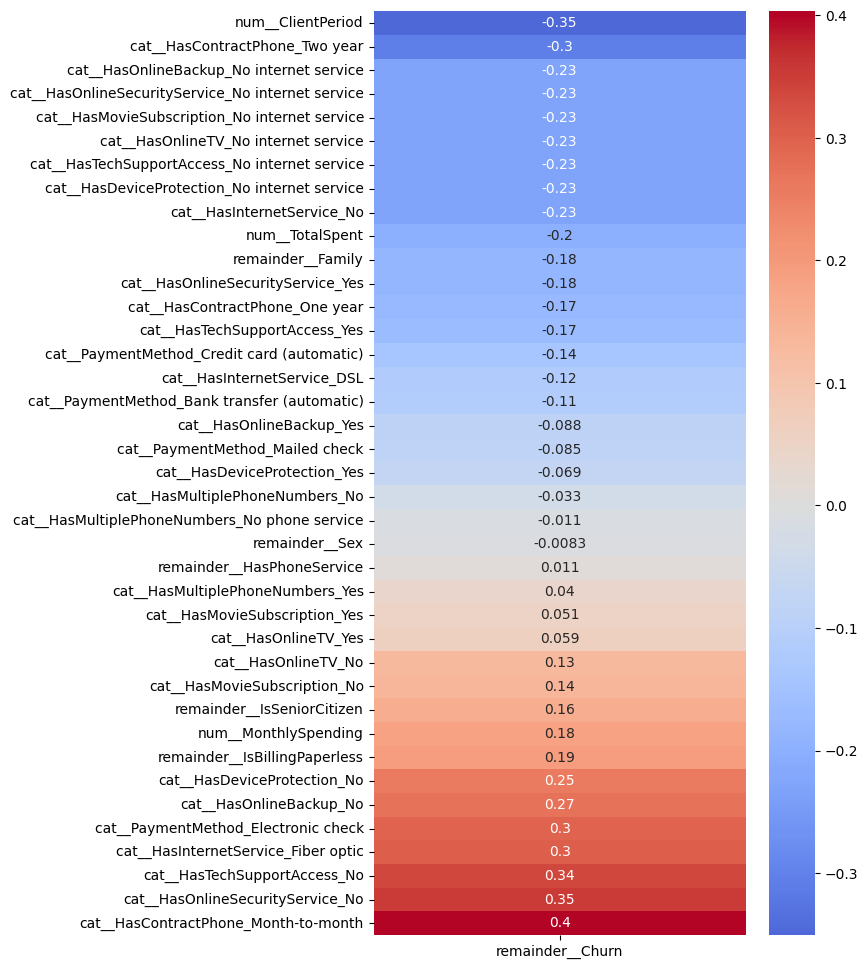

In [760]:
plt.figure(figsize=(6, 12))
sns.heatmap(
    target,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.show